# SVM(suport vector machine)
Support Vector Machines (SVMs) are powerful supervised learning algorithms used for classification, regression, and even outlier detection. They work by finding the optimal hyperplane that maximizes the margin between different classes, making them especially effective for high-dimensional and complex datasets

**Support vectors** are the key data points that define the decision boundary in a Support Vector Machine (SVM).

<img src="https://miro.medium.com/v2/resize:fit:1358/0*ktqQERR72flYedwh.png" width=600px height=400px alt="vectors ehich just touch boundary">

we have to minimize this margin such that no any vector(points) come inside the margin 

<img src="https://miro.medium.com/v2/resize:fit:1023/1*H4IDhr0W4OfqzUoxOmSgtQ.png" width=600px
height=400px>

<img src="https://miro.medium.com/max/1465/1*PiGj6vEyBhxbXfK4bzwwTg.png" width=400px height=300px>
this is problem with hard margin svm that it can't classify the points when another region points come in another region. so,to solve this problem soft margin svm comes into the picture

**Slack variable**
In Support Vector Machines (SVM), slack variables (denoted as ξᵢ) are introduced in the soft margin formulation to handle cases where the data is not linearly separable. These variables allow some flexibility by permitting certain data points to violate the margin constraints, enabling the SVM to find a balance between maximizing the margin and minimizing classification errors.
1. ξᵢ = 0 if the point lies on or outside the correct margin.
2. ξᵢ > 0 if the point is on the wrong side of the margin or misclassified.

<img src="https://teazrq.github.io/SMLR/images/SVMslack.png" width=400px height=300px>

**𝐿=1/n(∑max(0,1−𝑦𝑖⋅(𝐴𝑋1𝑖+𝐵𝑋2𝑖+𝐶)))**
after ξᵢ comes in picture the problem of hard margin svm solved it becomes soft margin svm

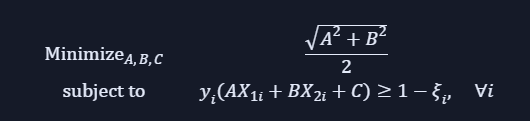   this is will create  problem of misclassification 

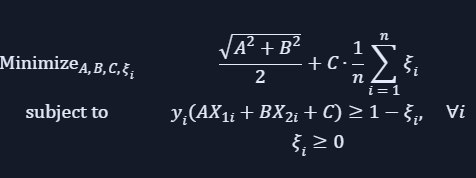 **C** is hyperparameter we decide which dominate

**SVM applicable only for linear datasets this is the problem with SVM** so,to overcome this the concept of **KERNEL** came into picture which takes the data to higher dimension first and make it linearly seprable in higher dimension and then project it into lower dimension 

<img src="https://tse1.mm.bing.net/th/id/OIP.62TusLbVgLCaaHT9-uSXEAHaCr?cb=thfc1falcon4&rs=1&pid=ImgDetMain&o=7&rm=3" width=500px height=400px>

# Types of kernel 
1. linear
2. rbf
3. polynomial
4. sigmoid

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
df=pd.read_csv(r"C:\Users\Sonu\OneDrive\Desktop\machine learning\SVM\pulsar_stars.csv")

In [ ]:
df['target_class'].value_counts()
# here we see that the data is imbalnced o is of 90% and 1 is of 10%

target_class
0    16259
1     1639
Name: count, dtype: int64

In [6]:
df.isnull().sum()

 Mean of the integrated profile                  0
 Standard deviation of the integrated profile    0
 Excess kurtosis of the integrated profile       0
 Skewness of the integrated profile              0
 Mean of the DM-SNR curve                        0
 Standard deviation of the DM-SNR curve          0
 Excess kurtosis of the DM-SNR curve             0
 Skewness of the DM-SNR curve                    0
target_class                                     0
dtype: int64

**outliers detection**
Handle outliers with SVMs¶
There are 2 variants of SVMs. They are hard-margin variant of SVM and soft-margin variant of SVM.

The hard-margin variant of SVM does not deal with outliers. In this case, we want to find the hyperplane with maximum margin such that every training point is correctly classified with margin at least 1. This technique does not handle outliers well.

Another version of SVM is called soft-margin variant of SVM. In this case, we can have a few points incorrectly classified or classified with a margin less than 1. But for every such point, we have to pay a penalty in the form of C parameter, which controls the outliers. Low C implies we are allowing more outliers and high C implies less outliers.

The message is that since the dataset contains outliers, so the value of C should be high while training the model.

In [16]:
x=df.iloc[:,:-1]
y=df.iloc[:,-1:]

In [17]:
x.head()

,Mean of the integrated profile,Standard deviation of the integrated profile,Excess kurtosis of the integrated profile,Skewness of the integrated profile,Mean of the DM-SNR curve,Standard deviation of the DM-SNR curve,Excess kurtosis of the DM-SNR curve,Skewness of the DM-SNR curve
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306


In [18]:
y.head()

,target_class
0,0
1,0
2,0
3,0
4,0


In [19]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [20]:
x_train.shape ,x_test.shape

((14318, 8), (3580, 8))

In [21]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

In [31]:
cols=df.columns
cols=cols.drop('target_class')
cols

Index([' Mean of the integrated profile',
       ' Standard deviation of the integrated profile',
       ' Excess kurtosis of the integrated profile',
       ' Skewness of the integrated profile', ' Mean of the DM-SNR curve',
       ' Standard deviation of the DM-SNR curve',
       ' Excess kurtosis of the DM-SNR curve',
       ' Skewness of the DM-SNR curve'],
      dtype='object')

In [33]:
x_train=pd.DataFrame(x_train,columns=[cols])
x_test=pd.DataFrame(x_test,columns=[cols])

In [34]:
x_train.describe()

,Mean of the integrated profile,Standard deviation of the integrated profile,Excess kurtosis of the integrated profile,Skewness of the integrated profile,Mean of the DM-SNR curve,Standard deviation of the DM-SNR curve,Excess kurtosis of the DM-SNR curve,Skewness of the DM-SNR curve
count,1.431800e+04,1.431800e+04,1.431800e+04,1.431800e+04,1.431800e+04,1.431800e+04,1.431800e+04,1.431800e+04
mean,6.848366e-17,-1.020307e-15,7.022056e-17,7.443876e-19,4.131351e-17,-1.409374e-16,-7.195746e-17,1.429224e-16
std,1.000035e+00,1.000035e+00,1.000035e+00,1.000035e+00,1.000035e+00,1.000035e+00,1.000035e+00,1.000035e+00
min,-4.112663e+00,-3.170535e+00,-2.091948e+00,-5.787887e-01,-4.207978e-01,-9.713859e-01,-2.543035e+00,-1.007302e+00
25%,-4.030299e-01,-6.104388e-01,-4.243778e-01,-3.178819e-01,-3.630399e-01,-6.100193e-01,-5.605791e-01,-6.574642e-01
50%,1.569867e-01,6.020556e-02,-2.392523e-01,-2.543766e-01,-3.330132e-01,-4.035778e-01,2.977024e-02,-2.058521e-01
75%,6.263383e-01,6.556022e-01,-2.434797e-03,-1.359383e-01,-2.433086e-01,1.059306e-01,5.351367e-01,3.294081e-01
max,3.100852e+00,7.610247e+00,7.164538e+00,1.079023e+01,7.143896e+00,4.323148e+00,5.823394e+00,1.022461e+01


# Run SVM with default hyperparameter
Default hyperparameter means C=1.0, kernel=rbf and gamma=auto among other parameters.

In [38]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,precision_score
svc=SVC()
svc1=SVC(C=100.0)
svc2=SVC(C=1000.0)
svc3=SVC(kernel='linear',C=1.0)
svc4=SVC(kernel='linear',C=100.0)
poly_svc=SVC(kernel='poly', C=1.0)
poly_svc100=SVC(kernel='poly', C=100.0) 


svc.fit(x_train,y_train)
svc1.fit(x_train,y_train)
svc2.fit(x_train,y_train)
svc3.fit(x_train,y_train)
svc4.fit(x_train,y_train)
poly_svc.fit(x_train,y_train)
poly_svc100.fit(x_train, y_train)



y_pred=svc.predict(x_test)
y_pred1=svc1.predict(x_test)
y_pred2=svc2.predict(x_test)
y_pred3=svc3.predict(x_test)
y_pred4=svc4.predict(x_test)
y_pred_poly=poly_svc.predict(x_test)
y_pred_poly1=poly_svc100.predict(x_test)


print('Model accuracy score with default hyperparameters: {0:0.4f}'. format(accuracy_score(y_test, y_pred)))
print('Model accuracy score with rbf kernel and C=100.0 : {0:0.4f}'. format(accuracy_score(y_test, y_pred1)))
print('Model accuracy score with rbf kernel and C=1000.0 : {0:0.4f}'. format(accuracy_score(y_test, y_pred2)))
print('Model accuracy score with linear kernel and C=1.0 : {0:0.4f}'. format(accuracy_score(y_test, y_pred3)))
print('Model accuracy score with linear kernel and C=100.0 : {0:0.4f}'. format(accuracy_score(y_test, y_pred4)))
print('Model accuracy score with polynomial kernel and C=1.0 : {0:0.4f}'. format(accuracy_score(y_test, y_pred_poly)))
print('Model accuracy score with polynomial kernel and C=100.0 : {0:0.4f}'. format(accuracy_score(y_test, y_pred_poly1)))

C:\Users\Sonu\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\Sonu\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\Sonu\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\Sonu\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1365: DataConve

Model accuracy score with default hyperparameters: 0.9807
Model accuracy score with rbf kernel and C=100.0 : 0.9816
Model accuracy score with rbf kernel and C=1000.0 : 0.9810
Model accuracy score with linear kernel and C=1.0 : 0.9802
Model accuracy score with linear kernel and C=100.0 : 0.9804
Model accuracy score with polynomial kernel and C=1.0 : 0.9765
Model accuracy score with polynomial kernel and C=100.0 : 0.9807


In [48]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print('Confusion matrix\n\n', cm)

print('\nTrue Positives(TP) = ', cm[0,0])

print('\nTrue Negatives(TN) = ', cm[1,1])

print('\nFalse Positives(FP) = ', cm[0,1])

print('\nFalse Negatives(FN) = ', cm[1,0])

precision=precision_score(y_test,y_pred)
print(precision)

Confusion matrix

 [[3230   13]
 [  56  281]]

True Positives(TP) =  3230

True Negatives(TN) =  281

False Positives(FP) =  13

False Negatives(FN) =  56
0.95578231292517


#  Hyperparameter Optimization using GridSearch CV

In [50]:
# import GridSearchCV
from sklearn.model_selection import GridSearchCV


# import SVC classifier
from sklearn.svm import SVC


# instantiate classifier with default hyperparameters with kernel=rbf, C=1.0 and gamma=auto
svc=SVC() 



# declare parameters for hyperparameter tuning
parameters = [ {'C':[1, 10, 100, 1000], 'kernel':['linear']},
               {'C':[1, 10, 100, 1000], 'kernel':['rbf'], 'gamma':[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]},
               {'C':[1, 10, 100, 1000], 'kernel':['poly'], 'degree': [2,3,4] ,'gamma':[0.01,0.02,0.03,0.04,0.05]} 
              ]




grid_search = GridSearchCV(estimator = svc,  
                           param_grid = parameters,
                           scoring = 'accuracy',
                           cv = 5,
                           verbose=0)


grid_search.fit(x_train, y_train)

C:\Users\Sonu\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\Sonu\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\Sonu\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\Sonu\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1365: DataConve

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'C': [1, 10, ...], 'kernel': ['linear']}, {'C': [1, 10, ...], 'gamma': [0.1, 0.2, ...], 'kernel': ['rbf']}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0C

In [51]:
print('GridSearch CV best score : {:.4f}\n\n'.format(grid_search.best_score_))
print('GridSearch CV best score : {:.4f}\n\n'.format(grid_search.best_score_))

GridSearch CV best score : 0.9793


GridSearch CV best score : 0.9793


